# Boerstler Data Analysis

30 respondents (identified by lat/lon pairs) each answered pairwise comparisons across up to 10 sessions.
Not all sessions were completed — session counts range from 1 to 12.

**Session detection:** the index column is a global time-order counter. Within a session, consecutive
index values are close together (gaps ≤ 121). A gap ≥ 200 signals a new session.

**Columns added here:**
- `person_id` — integer 0–28, one per unique (lat, lon) pair, ordered by first appearance
- `session_id` — integer 1–N per person, increments at each large gap in the index

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

df = pd.read_csv('boerstler_data.csv', index_col=0)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

# ── Person IDs ───────────────────────────────────────────────
# One unique ID per (lat, lon) pair, assigned in order of first appearance in the file.
coord_pairs = list(zip(df['LocationLatitude'], df['LocationLongitude']))
seen = {}
for pair in coord_pairs:
    if pair not in seen:
        seen[pair] = len(seen)
df['person_id'] = [seen[(lat, lon)] for lat, lon in coord_pairs]

# ── Session IDs ──────────────────────────────────────────────
# Within each person, sort rows by the global index and detect session
# boundaries as gaps > GAP_THRESHOLD in the index.
# ── Deduplicate person 21 ───────────────────────────────
# Person 21's data was recorded with every row duplicated.
# Drop exact duplicates within that person before assigning sessions.
feature_cols = ['lalco','ldep','llife','lcrim',
                'ralco','rdep','rlife','rcrim',
                'chosen','secElasped','order',
                'LocationLatitude','LocationLongitude']
pid21_mask = df['person_id'] == 21
df = pd.concat([
    df[~pid21_mask],
    df[pid21_mask].drop_duplicates(subset=feature_cols),
]).sort_index()
print(f'After dedup: {len(df):,} rows (removed {pid21_mask.sum() - pid21_mask.sum()//2} duplicate rows for person 21)')

# ── Session IDs ──────────────────────────────────────────
# Use only the order column reset as the session boundary signal.
# When order drops by more than 10, the respondent started a new session.
ORDER_RESET_THR = -10

session_ids = pd.Series(index=df.index, dtype=int)

for pid in df['person_id'].unique():
    mask = df['person_id'] == pid
    person_df = df[mask].sort_index()  # sort by global time order
    order_drop = person_df['order'].diff().fillna(0)
    new_session = order_drop < ORDER_RESET_THR
    session_num = new_session.cumsum() + 1  # 1-indexed
    session_ids[person_df.index] = session_num.values

df['session_id'] = session_ids

print(f'\nPerson IDs assigned: {df["person_id"].nunique()} unique people')
print(f'Session IDs assigned: max sessions per person = {df.groupby("person_id")["session_id"].max().max()}')
print()
print(df[['person_id', 'session_id', 'LocationLatitude', 'LocationLongitude']].head(10))

Loaded: 12,984 rows × 46 columns
After dedup: 12,369 rows (removed 612 duplicate rows for person 21)

Person IDs assigned: 29 unique people
Session IDs assigned: max sessions per person = 17.0

   person_id  session_id  LocationLatitude  LocationLongitude
0         27         1.0         37.914505        -122.300705
1         27         1.0         37.914505        -122.300705
2         27         1.0         37.914505        -122.300705
3         27         1.0         37.914505        -122.300705
4         27         1.0         37.914505        -122.300705
5         27         1.0         37.914505        -122.300705
6         27         1.0         37.914505        -122.300705
7         27         1.0         37.914505        -122.300705
8         10         1.0         53.423599          -2.311295
9         27         1.0         37.914505        -122.300705


In [7]:
# ── Per-person summary ───────────────────────────────────────
summary = (
    df.groupby('person_id')
    .agg(
        n_rows       = ('session_id', 'count'),
        n_sessions   = ('session_id', 'nunique'),
        lat          = ('LocationLatitude',  'first'),
        lon          = ('LocationLongitude', 'first'),
        timezone     = ('timezone_America/New_York', lambda x: x.iloc[0]),  # placeholder
    )
    .reset_index()
)

# Cleaner: just show lat/lon and session counts
summary_clean = (
    df.groupby('person_id')
    .agg(
        n_rows     = ('session_id', 'count'),
        n_sessions = ('session_id', 'nunique'),
        lat        = ('LocationLatitude',  'first'),
        lon        = ('LocationLongitude', 'first'),
    )
    .reset_index()
    .sort_values('person_id')
)

print(f'Per-person summary ({len(summary_clean)} people):')
print(summary_clean.to_string(index=False))
print(f'\nTotal rows: {summary_clean["n_rows"].sum():,}')
print(f'Sessions completed: {summary_clean["n_sessions"].describe().to_dict()}')

Per-person summary (29 people):
 person_id  n_rows  n_sessions       lat         lon
         0     600          10 52.618103   -1.180405
         1     600          10 40.238907  -77.193497
         2     590          10 44.760300  -85.617996
         3     590          10 42.111404  -77.942200
         4     660          11 54.774094   -3.439194
         5     600          10 33.344894  -82.082901
         6     530           9 25.658905  -80.355301
         7     600          10 38.257706  -85.709801
         8     600          10 50.733398   -1.924606
         9     600          10 47.663101 -122.302902
        10     590          10 53.423599   -2.311295
        11     960          17 52.439102   -1.503906
        12     600          10 54.324707   -2.744293
        13     120           2 53.755203   -1.759399
        14      50           1 39.835602  -84.267197
        15     590          10 42.965607  -85.650002
        16     590          10 31.993301  -96.419800
        17    

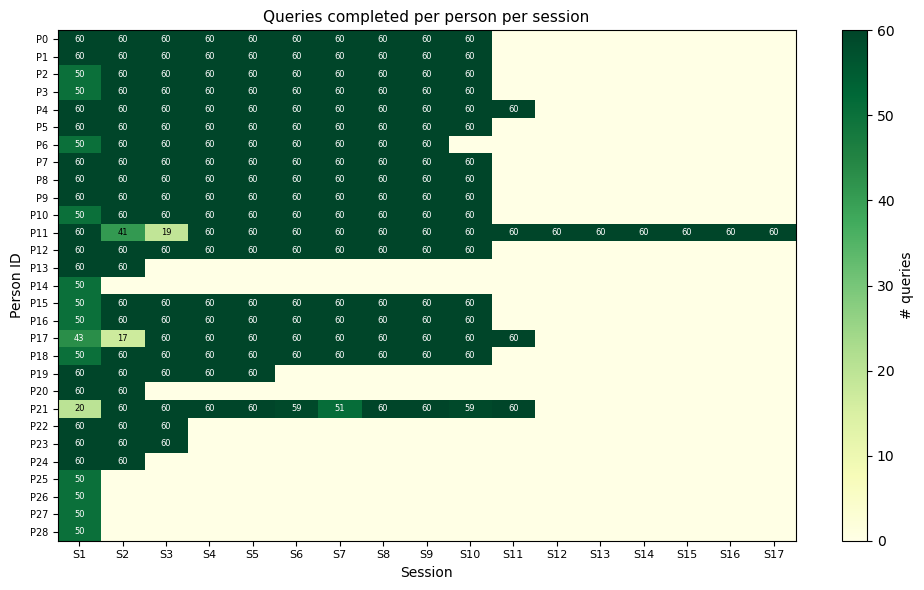

In [8]:
# ── Visualise sessions per person ────────────────────────────
# Heat-style bar showing how many queries each person completed per session.

session_counts = (
    df.groupby(['person_id', 'session_id'])
    .size()
    .reset_index(name='n_queries')
)

n_people   = df['person_id'].nunique()
max_sessions = int(session_counts['session_id'].max())

# Build matrix: rows = people, cols = sessions
grid = np.zeros((n_people, max_sessions))
for _, row in session_counts.iterrows():
    grid[int(row['person_id']), int(row['session_id']) - 1] = row['n_queries']

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(grid, aspect='auto', cmap='YlGn',
               vmin=0, vmax=grid.max())

# Annotate non-zero cells
for i in range(n_people):
    for j in range(max_sessions):
        v = int(grid[i, j])
        if v > 0:
            ax.text(j, i, str(v), ha='center', va='center', fontsize=6,
                    color='black' if v < grid.max() * 0.7 else 'white')

ax.set_xticks(range(max_sessions))
ax.set_xticklabels([f'S{j+1}' for j in range(max_sessions)], fontsize=8)
ax.set_yticks(range(n_people))
ax.set_yticklabels([f'P{i}' for i in range(n_people)], fontsize=7)
ax.set_xlabel('Session', fontsize=10)
ax.set_ylabel('Person ID', fontsize=10)
ax.set_title('Queries completed per person per session', fontsize=11)
plt.colorbar(im, ax=ax, label='# queries')
plt.tight_layout()
plt.show()

In [9]:
# ── Sanity check: show index ranges per session for one person ─
pid_to_check = 1  # change to inspect any person

person_df = df[df['person_id'] == pid_to_check].sort_index()
print(f'Person {pid_to_check} — index ranges per session:')
for sid, grp in person_df.groupby('session_id'):
    idx = grp.index
    print(f'  Session {sid}: index {idx.min()} – {idx.max()}  ({len(grp)} queries)')

Person 1 — index ranges per session:
  Session 1.0: index 1968 – 2066  (60 queries)
  Session 2.0: index 2622 – 2681  (60 queries)
  Session 3.0: index 3222 – 3283  (60 queries)
  Session 4.0: index 5022 – 5081  (60 queries)
  Session 5.0: index 5322 – 5381  (60 queries)
  Session 6.0: index 8664 – 8723  (60 queries)
  Session 7.0: index 9564 – 9623  (60 queries)
  Session 8.0: index 10704 – 10763  (60 queries)
  Session 9.0: index 11664 – 11723  (60 queries)
  Session 10.0: index 12024 – 12083  (60 queries)


In [11]:
# ── Save enriched CSV ────────────────────────────────────────
out_path = 'boerstler_data_labeled.csv'

# Put person_id and session_id as the first two columns for readability
cols = ['person_id', 'session_id'] + [c for c in df.columns if c not in ('person_id', 'session_id')]
df[cols].to_csv(out_path)

print(f'Saved to {out_path}')
print(f'Shape: {df.shape}')
print(df[['person_id', 'session_id']].head(8))

Saved to boerstler_data_labeled.csv
Shape: (12369, 48)
   person_id  session_id
0         27         1.0
1         27         1.0
2         27         1.0
3         27         1.0
4         27         1.0
5         27         1.0
6         27         1.0
7         27         1.0
